# Hyperparameter Optimization for CNN Model using Optuna

This notebook performs hyperparameter optimization on the CNN Mel Spectrogram classifier using [Optuna](https://optuna.org/).

We search over two hyperparameters:
- **Number of CNN blocks**
- **Number of features extracted in the conv layer**

The best configuration is then retrained for the full number of epochs and evaluated.

In [2]:
!pip install optuna torchsummary seaborn plotly

Please refresh your browser before continuing.

## Setup

We begin by importing all the packages and setting up folders.

In [3]:
import os
import numpy as np
import helperFncs as hf
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
FOLDER_TRAIN = '/mnt/share/Data-WearableAcoustic/Post_Mel/Train/'
FOLDER_VAL   = '/mnt/share/Data-WearableAcoustic/Post_Mel/Val/'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


Next, we load all the data.

In [4]:
def loadData(folderIn):
    fileList = sorted([f for f in os.listdir(folderIn) if f.endswith('.h5')])

    # Loading all the data into memory at once.
    mel = np.array([])
    labels = np.array([])
    for fileName in fileList:
        file_path = os.path.join(folderIn, fileName)
        data = hf.h5_to_dict(file_path)
        mel    = np.concatenate((mel, data['mel']), axis=0) if mel.size else data['mel']
        labels = np.concatenate((labels, data['labels']), axis=0) if labels.size else data['labels']

    # Add channel dimension: (N, n_mels, time_frames) -> (N, 1, n_mels, time_frames)
    # This is necessary for 2D CNNs which expect a channel dimension to comply with the (C, H, W) format
    # expected by Pytorch Conv2D layers.
    mel = mel[:, np.newaxis, :, :]

    return mel, labels

train_mel, train_labels = loadData(FOLDER_TRAIN)
val_mel,   val_labels   = loadData(FOLDER_VAL)

print(f'Training set:   {train_mel.shape}')
print(f'Validation set: {val_mel.shape}')

input_shape = train_mel.shape[1:]   # (1, n_mels, time_frames)
output_dim  = len(np.unique(train_labels))
print(f'Input shape: {input_shape},  Classes: {output_dim}')

# Pre-build tensors once — reused across all trials
X_train = torch.tensor(train_mel,   dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.long)
X_val   = torch.tensor(val_mel,     dtype=torch.float32)
y_val   = torch.tensor(val_labels,  dtype=torch.long)

Training set:   (35151, 1, 128, 126)
Validation set: (8746, 1, 128, 126)
Input shape: (1, 128, 126),  Classes: 4


## Dynamic CNN Model

The model is built dynamically from two hyperparameters:
- `n_blocks`: number of Conv → BatchNorm → ReLU → MaxPool blocks
- `no_features`: number of CNN features per block

In [5]:
class CNN_Optuna(nn.Module):
    """Dynamic CNN whose depth and width are controlled by hyperparameters.

    Args:
        input_shape  : (C, H, W)
        output_dim   : number of classes
        n_blocks     : number of Conv blocks
        no_features  : output CNN features extracted per block
    """
    def __init__(self, input_shape, output_dim, n_blocks=2, no_features=16):
        super().__init__()
        C, H, W = input_shape
        layers   = []
        in_ch    = C

        max_pool_size = 4
        for i in range(n_blocks):
            out_ch = no_features
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = max_pool_size),
            ]
            in_ch = out_ch

        self.features = nn.Sequential(*layers)

        # Compute flat dimension dynamically
        with torch.no_grad():
            dummy    = torch.zeros(1, C, H, W)
            flat_dim = self.features(dummy).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, output_dim),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def weighted_loss(device):
    """CrossEntropyLoss with class weights to handle imbalance."""
    weights = torch.tensor([5.0, 10.0, 10.0, 1.0], dtype=torch.float).to(device)
    return nn.CrossEntropyLoss(weight=weights)

Here is an example of a model for a particular choice of parameters.

In [6]:
# Plot model summary
from torchsummary import summary

n_blocks = 2
no_features = 16
model     = CNN_Optuna(input_shape, output_dim,
                        n_blocks=n_blocks,
                        no_features=no_features).to(device)
summary(model, input_size=input_shape)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 126]             160
              ReLU-2         [-1, 16, 128, 126]               0
         MaxPool2d-3           [-1, 16, 32, 31]               0
            Conv2d-4           [-1, 16, 32, 31]           2,320
              ReLU-5           [-1, 16, 32, 31]               0
         MaxPool2d-6             [-1, 16, 8, 7]               0
           Flatten-7                  [-1, 896]               0
            Linear-8                  [-1, 128]         114,816
              ReLU-9                  [-1, 128]               0
          Dropout-10                  [-1, 128]               0
           Linear-11                    [-1, 4]             516
Total params: 117,812
Trainable params: 117,812
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.06
Forward/

## Hyper-Parameter Search

We start by setting up the objective function.

In [7]:
OPTUNA_EPOCHS  = 6   # quick trials — increase for more accuracy
BATCH_SIZE     = 128

def objective(trial):
    # ── Suggest hyperparameters ───────────────────────────────────────────────
    n_blocks      = trial.suggest_int('n_blocks',      1,  3)
    no_features = trial.suggest_categorical('no_features', [4, 8, 16, 32, 64])
    #print(f"Model - n_blocks={n_blocks} - no_features={no_features}")

    # ── Build model ───────────────────────────────────────────────────────────
    model     = CNN_Optuna(input_shape, output_dim,
                           n_blocks=n_blocks,
                           no_features=no_features).to(device)
    criterion = weighted_loss(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loader = DataLoader(TensorDataset(X_train, y_train),
                              batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val, y_val),
                              batch_size=256, shuffle=False)

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(OPTUNA_EPOCHS):
        model.train()
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            optimizer.step()

        # Validation accuracy (used as Optuna objective)
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                preds    = torch.argmax(model(X_b), dim=1)
                correct += (preds == y_b).sum().item()
                total   += y_b.size(0)
        val_acc = correct / total
        #print(f"Epoch {epoch} - Val Accuracy = {val_acc}")

        # Pruning: stop bad trials early
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_acc

Running the hyper-parameter optimization.

In [8]:
N_TRIALS = 20   # increase for a more thorough search

# Selecting a parser that uses the Tree-structured Parzen Estimator (TPE) algorithm
sampler = optuna.samplers.TPESampler(seed=42)
# Prune if the trial’s best intermediate result is worse than median of intermediate results of
# previous trials at the same step. It stops unpromising trials early based on the intermediate
# results compared against the median of previous completed trials.
pruner  = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=3)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner,
    study_name='cnn_mel_hpo'
)

optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose output
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n{'='*50}")
print(f"Best trial:  #{study.best_trial.number}")
print(f"Best val acc: {study.best_value:.4f}")
print(f"Best params:  {study.best_params}")

[I 2026-04-15 21:47:08,834] A new study created in memory with name: cnn_mel_hpo


  0%|          | 0/20 [00:00<?, ?it/s]


Best trial:  #14
Best val acc: 0.8717
Best params:  {'n_blocks': 3, 'no_features': 32}


Let us know visualize the results.

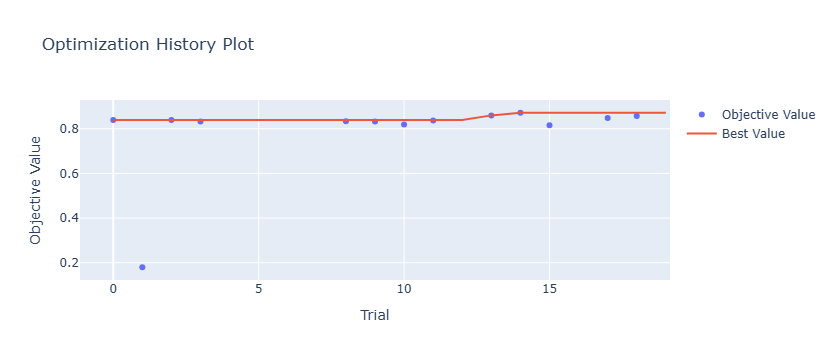

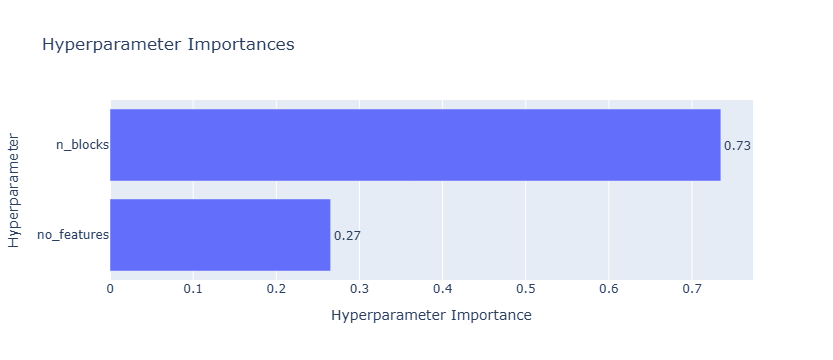

 number    value  params_n_blocks  params_no_features    state
     14 0.871713                3                  32 COMPLETE
     13 0.859936                3                  32 COMPLETE
     18 0.857306                3                  32 COMPLETE
     17 0.848731                3                  32 COMPLETE
      2 0.839012                3                  64 COMPLETE
      0 0.838783                2                   4 COMPLETE
     11 0.836497                3                  16 COMPLETE
      8 0.834096                2                   8 COMPLETE
     12 0.833981                3                  64   PRUNED
      9 0.833067                2                   4 COMPLETE
      3 0.832609                2                   8 COMPLETE
     10 0.819575                3                  64 COMPLETE
     15 0.815916                3                  32 COMPLETE
      4 0.814429                2                   4   PRUNED
     16 0.805282                3                  32  

In [9]:
# Optimization history - Displaying the history of objective values for the trials.
fig1 = plot_optimization_history(study)
fig1.show()

# Hyperparameter importances - In a few words, it computes the fraction of the total variance
# in the objective value that can be attributed to the specific parameter.
fig2 = plot_param_importances(study)
fig2.show()

# Manual summary table
import pandas as pd
df = study.trials_dataframe()
print(df[['number', 'value', 'params_n_blocks', 'params_no_features', 'state']]
      .sort_values('value', ascending=False)
      .to_string(index=False))

## Retrain Best Configuration for Full Epochs

In [10]:
FULL_EPOCHS = 20

best_n_blocks      = study.best_params['n_blocks']
best_no_features = study.best_params['no_features']

print(f'Retraining with n_blocks={best_n_blocks}, no_features={best_no_features}')
print(f'for {FULL_EPOCHS} epochs...')

model_best = CNN_Optuna(input_shape, output_dim,
                        n_blocks=best_n_blocks,
                        no_features=best_no_features).to(device)

criterion = weighted_loss(device)
optimizer = torch.optim.Adam(model_best.parameters(), lr=1e-3)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=256, shuffle=False)

best_val_loss = float('inf')
best_val_acc  = 0.0
train_losses  = []
val_accs      = []

for epoch in range(FULL_EPOCHS):
    model_best.train()
    running_loss = 0.0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model_best(X_b), y_b)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    model_best.eval()
    val_loss = correct = total = 0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out       = model_best(X_b)
            val_loss += criterion(out, y_b).item()
            preds     = torch.argmax(out, dim=1)
            correct  += (preds == y_b).sum().item()
            total    += y_b.size(0)

    val_acc = correct / total
    val_accs.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc  = val_acc
        torch.save(model_best.state_dict(), '_best_cnn_optuna.pth')
        print('... Model Saved')

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{FULL_EPOCHS}]  Loss: {avg_loss:.4f}  Val Acc: {val_acc:.4f}')

model_best.load_state_dict(torch.load('_best_cnn_optuna.pth'))
print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Retraining with n_blocks=3, no_features=32
for 20 epochs...
... Model Saved
... Model Saved
... Model Saved
... Model Saved
... Model Saved
Epoch [5/20]  Loss: 0.5361  Val Acc: 0.8398
... Model Saved
Epoch [10/20]  Loss: 0.4617  Val Acc: 0.8522
... Model Saved
Epoch [15/20]  Loss: 0.4059  Val Acc: 0.8694
Epoch [20/20]  Loss: 0.3750  Val Acc: 0.8476

Best Val Accuracy: 0.8698


Displaying the learning curves

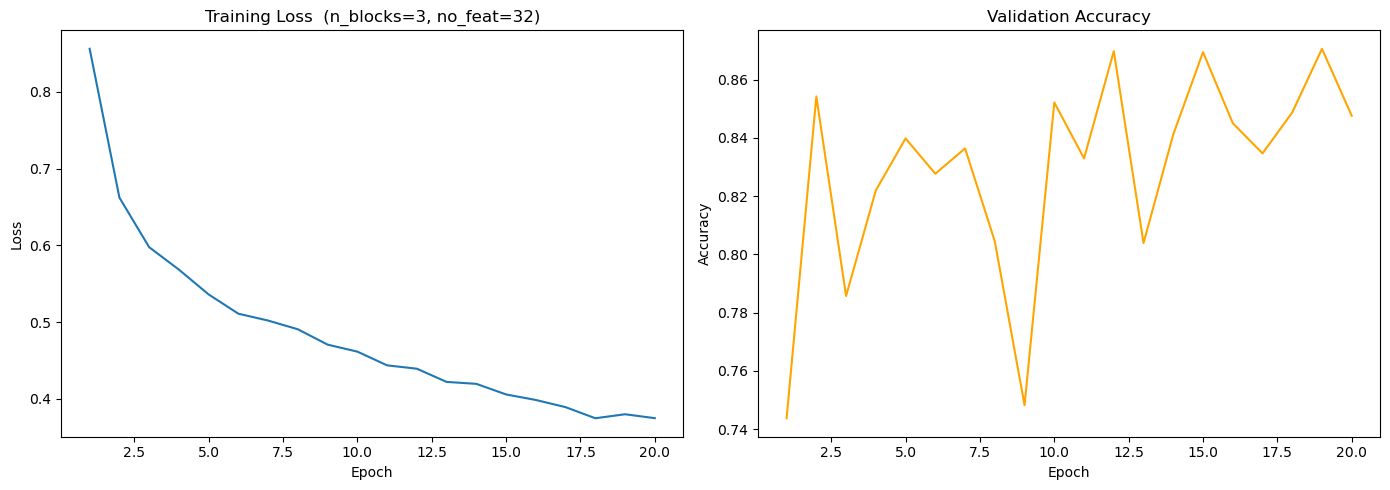

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, FULL_EPOCHS + 1), train_losses)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title(f'Training Loss  (n_blocks={best_n_blocks}, no_feat={best_no_features})')

ax2.plot(range(1, FULL_EPOCHS + 1), val_accs, color='orange')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')

plt.tight_layout()
plt.show()

Final evaluation of the best model.

Validation Accuracy : 0.8698
Validation F1 Score : 0.8760

Classification Report:
              precision    recall  f1-score   support

      Speech       0.77      0.91      0.84      1572
       Cough       0.43      0.75      0.54       427
  Non-Verbal       0.36      0.28      0.32       341
       Other       0.98      0.90      0.94      6406

    accuracy                           0.87      8746
   macro avg       0.64      0.71      0.66      8746
weighted avg       0.89      0.87      0.88      8746



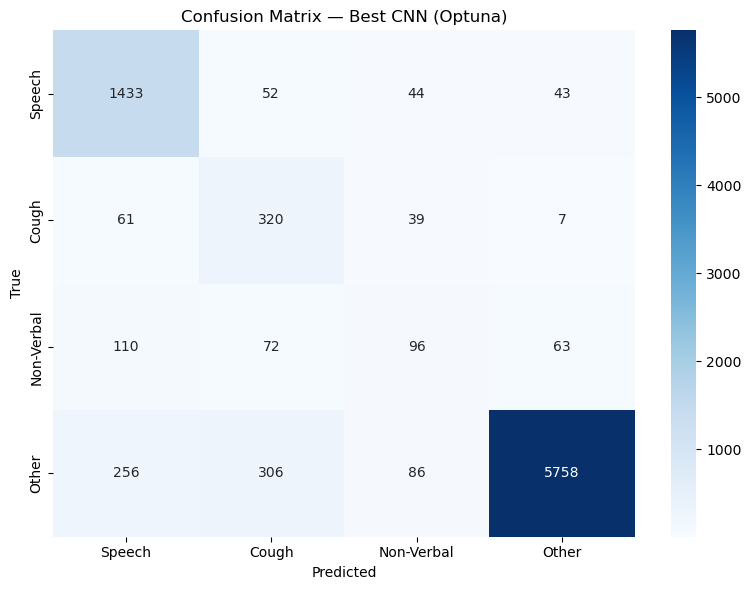

In [12]:
model_best.eval()
val_preds, val_true = [], []
with torch.no_grad():
    for X_b, y_b in val_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        preds = torch.argmax(model_best(X_b), dim=1)
        val_preds.extend(preds.cpu().numpy())
        val_true.extend(y_b.cpu().numpy())

val_preds = np.array(val_preds)
val_true  = np.array(val_true)

accuracy = accuracy_score(val_true, val_preds)
f1       = f1_score(val_true, val_preds, average='weighted')
cm       = confusion_matrix(val_true, val_preds)

print(f'Validation Accuracy : {accuracy:.4f}')
print(f'Validation F1 Score : {f1:.4f}')
print('\nClassification Report:')
print(classification_report(val_true, val_preds,
      target_names=['Speech', 'Cough', 'Non-Verbal', 'Other']))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Speech','Cough','Non-Verbal','Other'],
            yticklabels=['Speech','Cough','Non-Verbal','Other'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — Best CNN (Optuna)')
plt.tight_layout()
plt.show()